# Current Actor — Diverse Fresh Replay / Cost Critic-only Refit

episode-dual `n=10` Mini Pilotの最終Actorを固定し、未知geometryへのCost推定失敗が**データ多様性・Critic追従不足**で改善するかを検証します。

1. validationと重複しない100 unique geometry/N（N=2/4/8）を固定Actorで各1 rollout収集
2. Actor・Reward Critic・α・λをfreeze
3. 現在のCost Criticだけを `n=10` で追加学習
4. 0 / 5k / 20k updateを、先ほどの60 geometry × 3 rolloutで再評価

Cost Criticは全seedで同一checkpointから開始し、Replay samplingとbootstrap action乱数だけを3 seedに分けます。

In [1]:
from pathlib import Path
from copy import deepcopy
import gc, hashlib, json, math, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT=Path.cwd().resolve()
if not (ROOT/'uav_safe_marl').is_dir(): ROOT=ROOT.parent
SOURCE_RUN=ROOT/'runs'/'online_cal_n10_episode_dual_dcost6_mps'
SOURCE_CHECKPOINT=SOURCE_RUN/'checkpoints'/'final.pt'
TRAIN_BANK_PATH=ROOT/'runs'/'scenario_diversity_confirmation'/'banks'/'c_unique_100_per_n.json'
VALIDATION_BANK_PATH=ROOT/'runs'/'scenario_diversity_confirmation'/'banks'/'validation_20_per_n.json'
VALIDATION_ROWS_PATH=ROOT/'runs'/'episode_dual_large_calibration'/'large_calibration.jsonl'
OUTPUT_RUN=ROOT/'runs'/'current_actor_cost_critic_refit'
REPLAY_PATH=OUTPUT_RUN/'fresh_diverse_replay.pt'
VALIDATION_CORPUS_PATH=OUTPUT_RUN/'validation_start_corpus.pt'
COST_CRITIC_SEEDS=[0,1,2]
MILESTONES=[0,5_000,20_000]
COST_N_STEP=10
REPLAY_CAPACITY=200_000
RECOLLECT=False
REBUILD_VALIDATION_CORPUS=False
RETRAIN=False
for path in (SOURCE_CHECKPOINT,TRAIN_BANK_PATH,VALIDATION_BANK_PATH,VALIDATION_ROWS_PATH):
    if not path.exists(): raise FileNotFoundError(path)
OUTPUT_RUN.mkdir(parents=True,exist_ok=True)
print({'output':str(OUTPUT_RUN),'cost_seeds':COST_CRITIC_SEEDS,'milestones':MILESTONES})

{'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/current_actor_cost_critic_refit', 'cost_seeds': [0, 1, 2], 'milestones': [0, 5000, 20000]}


In [2]:
print({'platform':platform.platform(),'python':platform.python_version(),'torch':torch.__version__,'mps_available':torch.backends.mps.is_available()})
if not torch.backends.mps.is_available(): raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe=torch.ones((128,128),device='mps'); print({'device':str(probe.device),'probe':float((probe@probe).sum().cpu())}); del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


In [3]:
from uav_safe_marl import build_env,load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer

training_scenarios=load_scenario_bank(TRAIN_BANK_PATH)
validation_scenarios=load_scenario_bank(VALIDATION_BANK_PATH)
assert len(training_scenarios)==300 and len(validation_scenarios)==60
assert not ({s['scenario_id'] for s in training_scenarios}&{s['scenario_id'] for s in validation_scenarios})
assert all(sum(int(s['actual_agent_count'])==n for s in training_scenarios)==100 for n in (2,4,8))
overrides=json.loads((SOURCE_RUN/'resolved_config.json').read_text(encoding='utf-8'))
overrides['device']='mps'; overrides['learning']['buffer_size']=REPLAY_CAPACITY
maximum_reference_time=max(max(s['reference_arrival_times']) for s in training_scenarios+validation_scenarios)
overrides['environment']['max_steps']=max(overrides['environment']['max_steps'],int(math.ceil(2.0*maximum_reference_time/overrides['environment']['dt_base'])))
overrides['training'].update({'total_environment_steps_budget':None,'checkpoint_every_episodes':10})
overrides['monitoring'].update({'enabled':True,'progress_bar':True,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
config=load_config(ROOT/'configs'/'full.yaml',overrides=overrides)
SOURCE_SHA=hashlib.sha256(SOURCE_CHECKPOINT.read_bytes()).hexdigest(); TRAIN_SHA=hashlib.sha256(TRAIN_BANK_PATH.read_bytes()).hexdigest(); VALIDATION_SHA=hashlib.sha256(VALIDATION_ROWS_PATH.read_bytes()).hexdigest()
print({'training_geometry':len(training_scenarios),'validation_geometry':len(validation_scenarios),'overlap':0,'max_steps':config.environment.max_steps,'replay_capacity':config.learning.buffer_size})

{'training_geometry': 300, 'validation_geometry': 60, 'overlap': 0, 'max_steps': 1722, 'replay_capacity': 200000}


## 1. 固定Actorによるfresh diverse replay収集

10 episodeごとにcollection checkpointを保存します。中断後はscenario順序・Replay・乱数状態を含めて再開します。

In [4]:
def module_snapshot(module): return {k:v.detach().cpu().clone() for k,v in module.state_dict().items()}
def frozen_snapshot(t): return {'actor':module_snapshot(t.backend.actor),'reward':module_snapshot(t.backend.reward_critics),'reward_target':module_snapshot(t.backend.reward_targets),'cost':module_snapshot(t.backend.cost_critics),'alpha':t.backend.log_alpha.detach().cpu().clone(),'lambda':float(t.backend.dual.value)}
def assert_collection_frozen(t,b):
    for key,module in [('actor',t.backend.actor),('reward',t.backend.reward_critics),('reward_target',t.backend.reward_targets),('cost',t.backend.cost_critics)]:
        if not all(torch.equal(v,module.state_dict()[k].detach().cpu()) for k,v in b[key].items()): raise RuntimeError(f'{key} changed during collection')
    if not torch.equal(b['alpha'],t.backend.log_alpha.detach().cpu()) or b['lambda']!=float(t.backend.dual.value): raise RuntimeError('alpha/lambda changed during collection')

collection_checkpoint=OUTPUT_RUN/'collection_checkpoint.pt'
if REPLAY_PATH.exists() and not RECOLLECT:
    payload=torch.load(REPLAY_PATH,map_location='cpu',weights_only=False)
    if payload['source_sha256']!=SOURCE_SHA or payload['training_bank_sha256']!=TRAIN_SHA: raise RuntimeError('fresh replay cache mismatch')
    print({'cached_replay_transitions':payload['transition_count'],'by_N':payload['occupancy_by_n']})
else:
    collector=SafeRLTrainer(config,build_env(config),OUTPUT_RUN/'collection')
    if collection_checkpoint.exists() and not RECOLLECT:
        collector.load_checkpoint(collection_checkpoint,resume_training=True); collector.logger.truncate_after_episode(collector.completed_episodes)
        print(f'{collector.completed_episodes} rollout地点から収集を再開します。')
    else: collector.load_checkpoint(SOURCE_CHECKPOINT,resume_training=False)
    before=frozen_snapshot(collector); remaining=len(training_scenarios)-collector.completed_episodes
    try:
        if remaining>0: collector.train(episodes=remaining,scenarios=training_scenarios,live_display=True,checkpoint_path=collection_checkpoint,update_mode='collect_only')
        assert_collection_frozen(collector,before)
        if len(collector.buffer)!=sum(collector.buffer.occupancy_by_agent_count().values()): raise RuntimeError('Replay overflow: increase capacity')
        torch.save({'source_sha256':SOURCE_SHA,'training_bank_sha256':TRAIN_SHA,'replay_buffer':collector.buffer.state_dict(),'transition_count':len(collector.buffer),'occupancy_by_n':collector.buffer.occupancy_by_agent_count()},REPLAY_PATH)
        print({'collected_rollouts':collector.completed_episodes,'transitions':len(collector.buffer),'by_N':collector.buffer.occupancy_by_agent_count(),'frozen_audit':'passed'})
    finally: collector.env.close()
    del collector; gc.collect(); torch.mps.empty_cache()

Training:   0%|          | 0/300 [00:00<?, ?episode/s]

{'collected_rollouts': 300, 'transitions': 137719, 'by_N': {2: 43292, 4: 45126, 8: 49301}, 'frozen_audit': 'passed'}


## 2. 既存180 rolloutを再評価可能なStart-state corpusへ変換

MC returnと初回stochastic actionは既存結果を保持し、scenarioから初期graphだけを決定論的に再構築します。milestone 0で旧UCBと一致することを監査します。

In [5]:
validation_rows=[json.loads(x) for x in VALIDATION_ROWS_PATH.read_text(encoding='utf-8').splitlines() if x.strip()]
scenario_by_id={s['scenario_id']:s for s in validation_scenarios}
if VALIDATION_CORPUS_PATH.exists() and not REBUILD_VALIDATION_CORPUS:
    payload=torch.load(VALIDATION_CORPUS_PATH,map_location='cpu',weights_only=False)
    if payload['source_sha256']!=SOURCE_SHA or payload['validation_rows_sha256']!=VALIDATION_SHA: raise RuntimeError('validation corpus mismatch')
    validation_corpus=payload['corpus']
else:
    reconstructor=SafeRLTrainer(config,build_env(config),OUTPUT_RUN/'validation_reconstruction'); reconstructor.load_checkpoint(SOURCE_CHECKPOINT,resume_training=False); validation_corpus=[]
    try:
        observations={}
        for sid,scenario in tqdm(scenario_by_id.items(),desc='Reconstruct validation starts'):
            _,info=reconstructor.env.reset(options={'scenario':scenario}); reconstructor.communication.reset(info['predicted_los_edges']); observations[sid]=reconstructor._policy_observation({})
        errors=[]
        for row in validation_rows:
            obs=observations[row['scenario_id']]; action=np.asarray(row['conditioned_initial_execution_action'],dtype=np.float64); q=reconstructor.backend.start_cost_statistics_for_action(obs,action); errors.append(abs(q['ucb']-row['start_state_cost_ucb']))
            validation_corpus.append({'scenario_id':row['scenario_id'],'actual_agent_count':int(row['actual_agent_count']),'repeat':int(row['repeat']),'mc':float(row['discounted_episode_cost']),'start_observation':obs,'start_action':action})
        if max(errors)>1e-4: raise RuntimeError(f'milestone-0 reconstruction mismatch: {max(errors)}')
        torch.save({'source_sha256':SOURCE_SHA,'validation_rows_sha256':VALIDATION_SHA,'corpus':validation_corpus,'max_reconstruction_error':max(errors)},VALIDATION_CORPUS_PATH)
        print({'validation_rows':len(validation_corpus),'unique_scenarios':len(observations),'max_UCB_reconstruction_error':max(errors)})
    finally: reconstructor.env.close()
    del reconstructor; gc.collect(); torch.mps.empty_cache()

Reconstruct validation starts:   0%|          | 0/60 [00:00<?, ?it/s]

{'validation_rows': 180, 'unique_scenarios': 60, 'max_UCB_reconstruction_error': 0.0}


## 3. Cost Critic-only n=10追加学習

Actor・Reward Critic・target・α・λが変化しないことを各milestoneで確認します。

In [6]:
def rankdata(x):
    x=np.asarray(x,float); order=np.argsort(x,kind='mergesort'); ranks=np.empty(len(x)); i=0
    while i<len(x):
        j=i+1
        while j<len(x) and x[order[j]]==x[order[i]]: j+=1
        ranks[order[i:j]]=(i+j-1)/2+1; i=j
    return ranks
def corr(a,b): return None if len(a)<2 or np.std(a)==0 or np.std(b)==0 else float(np.corrcoef(a,b)[0,1])
def assert_non_cost_frozen(t,b):
    for key,module in [('actor',t.backend.actor),('reward',t.backend.reward_critics),('reward_target',t.backend.reward_targets)]:
        if not all(torch.equal(v,module.state_dict()[k].detach().cpu()) for k,v in b[key].items()): raise RuntimeError(f'{key} changed')
    if not torch.equal(b['alpha'],t.backend.log_alpha.detach().cpu()) or b['lambda']!=float(t.backend.dual.value): raise RuntimeError('alpha/lambda changed')
def evaluate_start(t,seed,milestone):
    rr=[]
    for item in tqdm(validation_corpus,desc=f'seed{seed}@{milestone}',leave=False):
        q=t.backend.start_cost_statistics_for_action(item['start_observation'],item['start_action']); rr.append({'seed':seed,'milestone':milestone,'scenario_id':item['scenario_id'],'actual_agent_count':item['actual_agent_count'],'repeat':item['repeat'],'mc':item['mc'],'q_mean':q['mean'],'q_ucb':q['ucb']})
    sr=[]
    for sid in sorted({r['scenario_id'] for r in rr}):
        g=[r for r in rr if r['scenario_id']==sid]; sr.append({'scenario_id':sid,'actual_agent_count':g[0]['actual_agent_count'],'mc':float(np.mean([r['mc'] for r in g])),'q_ucb':float(np.mean([r['q_ucb'] for r in g]))})
    mc=np.asarray([r['mc'] for r in sr]); q=np.asarray([r['q_ucb'] for r in sr]); actual=mc>config.learning.d_cost; pred=q>config.learning.d_cost; tp=int(np.sum(actual&pred)); fn=int(np.sum(actual&~pred)); tn=int(np.sum(~actual&~pred)); fp=int(np.sum(~actual&pred))
    summary={'seed':seed,'milestone':milestone,'mc_mean':float(mc.mean()),'ucb_mean':float(q.mean()),'bias':float(np.mean(q-mc)),'mae':float(np.mean(abs(q-mc))),'rmse':float(np.sqrt(np.mean((q-mc)**2))),'pearson':corr(mc,q),'spearman':corr(rankdata(mc),rankdata(q)),'coverage':float(np.mean(mc<=q)),'false_negative_rate':fn/max(1,tp+fn),'false_positive_rate':fp/max(1,tn+fp),'confusion':{'tp':tp,'fn':fn,'tn':tn,'fp':fp},'by_n':{}}
    for n in (2,4,8):
        g=[r for r in sr if r['actual_agent_count']==n]; a=np.asarray([r['mc'] for r in g]); b=np.asarray([r['q_ucb'] for r in g]); summary['by_n'][str(n)]={'mc_mean':float(a.mean()),'ucb_mean':float(b.mean()),'mae':float(np.mean(abs(a-b))),'pearson':corr(a,b)}
    return summary
def load_arm(seed):
    t=SafeRLTrainer(config,build_env(config),OUTPUT_RUN/f'seed{seed}'); t.load_checkpoint(SOURCE_CHECKPOINT,resume_training=False)
    payload=torch.load(REPLAY_PATH,map_location='cpu',weights_only=False); t.buffer.load_state_dict(payload['replay_buffer']); t.buffer.load_sampling_state_dict(np.random.default_rng(710_000+seed).bit_generator.state); del payload
    torch.manual_seed(720_000+seed); torch.mps.manual_seed(720_000+seed); return t
def rng_state(): return {'cpu':torch.get_rng_state(),'mps':torch.mps.get_rng_state()}
def set_rng_state(state): torch.set_rng_state(state['cpu'].cpu()); torch.mps.set_rng_state(state['mps'].cpu())
def run_seed(seed):
    out=OUTPUT_RUN/f'seed{seed}'; out.mkdir(parents=True,exist_ok=True); t=load_arm(seed); before=frozen_snapshot(t); results=[]; updates=[]; current=0
    for milestone in MILESTONES:
        ckpt=out/f'backend_{milestone:06d}.pt'
        if ckpt.exists() and not RETRAIN:
            saved=torch.load(ckpt,map_location=t.backend.device,weights_only=False); t.backend.load_state_dict(saved['backend']); t.buffer.load_sampling_state_dict(saved['replay_sampling_state']); set_rng_state(saved['torch_rng_state']); current=milestone
        else:
            for u in tqdm(range(current,milestone),desc=f'seed{seed} Cost-only n=10'):
                batch=t.buffer.sample_n_step(config.learning.batch_size,COST_N_STEP,config.learning.gamma_cost); metrics=t.backend.update_cost_critic_only_n_step(batch)
                if (u+1)%100==0: updates.append({'seed':seed,'updates':u+1,**metrics})
            current=milestone; torch.save({'backend':t.backend.state_dict(),'replay_sampling_state':t.buffer.sampling_state_dict(),'torch_rng_state':rng_state()},ckpt)
        assert_non_cost_frozen(t,before); result=evaluate_start(t,seed,milestone); results.append(result); print(result)
    (out/'summary.json').write_text(json.dumps(results,indent=2),encoding='utf-8')
    with (out/'cost_updates.jsonl').open('w') as f:
        for row in updates:f.write(json.dumps(row)+'\n')
    t.env.close(); del t; gc.collect(); torch.mps.empty_cache(); return results
all_results={seed:run_seed(seed) for seed in COST_CRITIC_SEEDS}

seed0 Cost-only n=10: 0it [00:00, ?it/s]

seed0@0:   0%|          | 0/180 [00:00<?, ?it/s]

{'seed': 0, 'milestone': 0, 'mc_mean': 10.172580429320126, 'ucb_mean': 34.639804105957346, 'bias': 24.46722367663723, 'mae': 30.842331031532993, 'rmse': 46.807049337744964, 'pearson': 0.005970415046458063, 'spearman': 0.2358650931478439, 'coverage': 0.8, 'false_negative_rate': 0.08, 'false_positive_rate': 0.6571428571428571, 'confusion': {'tp': 23, 'fn': 2, 'tn': 12, 'fp': 23}, 'by_n': {'2': {'mc_mean': 0.9864612307845034, 'ucb_mean': 38.913105025887496, 'mae': 38.0580481031789, 'pearson': 0.04567169825221858}, '4': {'mc_mean': 5.839389209701787, 'ucb_mean': 31.582869283358256, 'mae': 27.737579965311006, 'pearson': 0.12740896106101465}, '8': {'mc_mean': 23.69189084747407, 'ucb_mean': 33.4234380086263, 'mae': 26.731365026109103, 'pearson': 0.007833907353962381}}}


seed0 Cost-only n=10:   0%|          | 0/5000 [00:00<?, ?it/s]

seed0@5000:   0%|          | 0/180 [00:00<?, ?it/s]

...

seed2@5000:   0%|          | 0/180 [00:00<?, ?it/s]

{'seed': 2, 'milestone': 5000, 'mc_mean': 10.172580429320126, 'ucb_mean': 11.163558227154944, 'bias': 0.9909777978348228, 'mae': 7.838976876105986, 'rmse': 10.469335558006042, 'pearson': 0.6924588134869122, 'spearman': 0.6729687548060027, 'coverage': 0.6833333333333333, 'false_negative_rate': 0.08, 'false_positive_rate': 0.42857142857142855, 'confusion': {'tp': 23, 'fn': 2, 'tn': 20, 'fp': 15}, 'by_n': {'2': {'mc_mean': 0.9864612307845034, 'ucb_mean': 3.6080404311418532, 'mae': 3.5964561171403147, 'pearson': 0.022649120685842943}, '4': {'mc_mean': 5.839389209701787, 'ucb_mean': 10.369019261995952, 'mae': 9.013443792360473, 'pearson': 0.16518032239952798}, '8': {'mc_mean': 23.69189084747407, 'ucb_mean': 19.513614988327024, 'mae': 10.907030718817172, 'pearson': 0.5246105598436176}}}


seed2 Cost-only n=10:   0%|          | 0/15000 [00:00<?, ?it/s]

seed2@20000:   0%|          | 0/180 [00:00<?, ?it/s]

{'seed': 2, 'milestone': 20000, 'mc_mean': 10.172580429320126, 'ucb_mean': 13.55836016833782, 'bias': 3.385779739017701, 'mae': 10.727047150328584, 'rmse': 15.315159426626824, 'pearson': 0.37729308789206756, 'spearman': 0.4776886467040938, 'coverage': 0.7166666666666667, 'false_negative_rate': 0.12, 'false_positive_rate': 0.45714285714285713, 'confusion': {'tp': 22, 'fn': 3, 'tn': 19, 'fp': 16}, 'by_n': {'2': {'mc_mean': 0.9864612307845034, 'ucb_mean': 6.954862071077029, 'mae': 7.030561817394757, 'pearson': -0.11722275060443765}, '4': {'mc_mean': 5.839389209701787, 'ucb_mean': 13.514580170313513, 'mae': 12.19442881358868, 'pearson': -0.13213834873373842}, '8': {'mc_mean': 23.69189084747407, 'ucb_mean': 20.20563826362292, 'mae': 12.95615082000231, 'pearson': 0.3546369344704786}}}


## 4. Seed集約と判定

{'0': {'mae': {'mean': 30.842331031532993,
   'values': [30.842331031532993, 30.842331031532993, 30.842331031532993]},
  'rmse': {'mean': 46.807049337744964,
   'values': [46.807049337744964, 46.807049337744964, 46.807049337744964]},
  'bias': {'mean': 24.46722367663723,
   'values': [24.46722367663723, 24.46722367663723, 24.46722367663723]},
  'pearson': {'mean': 0.005970415046458063,
   'values': [0.005970415046458063,
    0.005970415046458063,
    0.005970415046458063]},
  'spearman': {'mean': 0.2358650931478439,
   'values': [0.2358650931478439, 0.2358650931478439, 0.2358650931478439]},
  'coverage': {'mean': 0.8000000000000002, 'values': [0.8, 0.8, 0.8]},
  'false_negative_rate': {'mean': 0.08, 'values': [0.08, 0.08, 0.08]},
  'false_positive_rate': {'mean': 0.6571428571428571,
   'values': [0.6571428571428571, 0.6571428571428571, 0.6571428571428571]},
  'ucb_mean': {'mean': 34.639804105957346,
   'values': [34.639804105957346, 34.639804105957346, 34.639804105957346]},
  'by_n': {

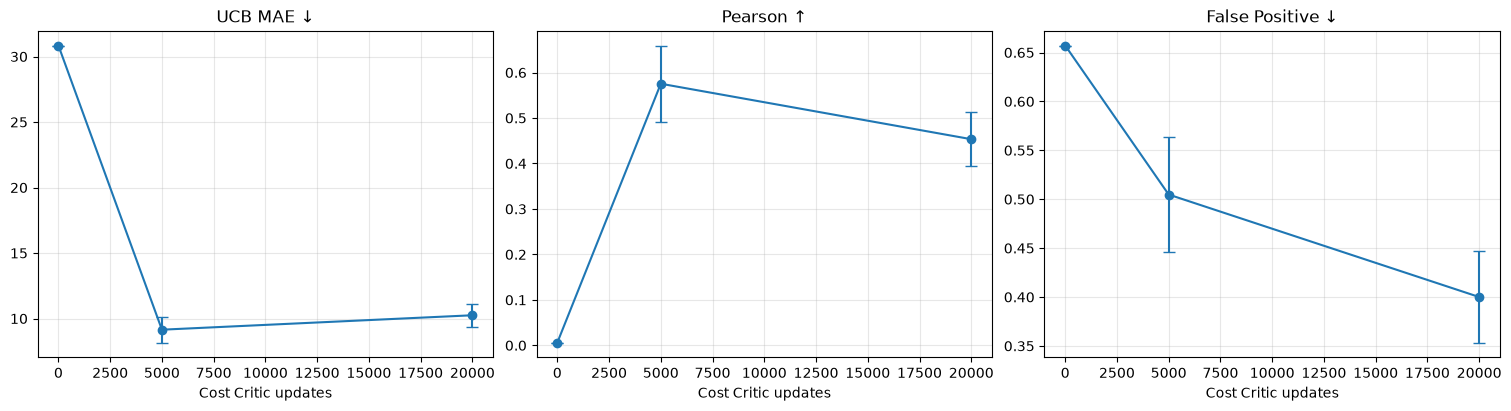

{'decision': {'mae_improved': True, 'pearson_improved': True, 'false_positive_improved': True, 'danger_miss_not_worse': False}, 'report': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/current_actor_cost_critic_refit/final_report.json', 'figure': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/current_actor_cost_critic_refit/cost_critic_refit.png'}


In [7]:
metrics=['mae','rmse','bias','pearson','spearman','coverage','false_negative_rate','false_positive_rate','ucb_mean']
aggregate={}
for j,milestone in enumerate(MILESTONES):
    rows=[all_results[s][j] for s in COST_CRITIC_SEEDS]; aggregate[str(milestone)]={key:{'mean':float(np.mean([r[key] for r in rows])),'values':[r[key] for r in rows]} for key in metrics}; aggregate[str(milestone)]['by_n']={str(n):{key:float(np.mean([r['by_n'][str(n)][key] for r in rows])) for key in ('mc_mean','ucb_mean','mae','pearson')} for n in (2,4,8)}
report={'definition':'Current fixed Actor, fresh 100 geometry/N replay, Cost Critic-only n=10 refit','design':{'source_checkpoint_sha256':SOURCE_SHA,'training_bank_sha256':TRAIN_SHA,'validation_rows_sha256':VALIDATION_SHA,'cost_seeds':COST_CRITIC_SEEDS,'milestones':MILESTONES,'cost_n_step':COST_N_STEP},'aggregate':aggregate,'by_seed':all_results}
(OUTPUT_RUN/'final_report.json').write_text(json.dumps(report,indent=2),encoding='utf-8'); display(aggregate)
fig,axes=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
for ax,key,title in zip(axes,['mae','pearson','false_positive_rate'],['UCB MAE ↓','Pearson ↑','False Positive ↓']):
    means=[aggregate[str(m)][key]['mean'] for m in MILESTONES]; errors=[np.std(aggregate[str(m)][key]['values']) for m in MILESTONES]; ax.errorbar(MILESTONES,means,yerr=errors,marker='o',capsize=4); ax.set_title(title); ax.set_xlabel('Cost Critic updates'); ax.grid(alpha=.3)
figure_path=OUTPUT_RUN/'cost_critic_refit.png'; fig.savefig(figure_path,dpi=170); plt.show()
before=aggregate['0']; after=aggregate['20000']; decision={'mae_improved':after['mae']['mean']<before['mae']['mean'],'pearson_improved':after['pearson']['mean']>before['pearson']['mean'],'false_positive_improved':after['false_positive_rate']['mean']<before['false_positive_rate']['mean'],'danger_miss_not_worse':after['false_negative_rate']['mean']<=before['false_negative_rate']['mean']}
print({'decision':decision,'report':str(OUTPUT_RUN/'final_report.json'),'figure':str(figure_path)})